# `own_night` 41장 — 6종 모델 성능·용량·속도 비교

9/1 45장 병합 후 사용자가 **4장을 수동 삭제**(`own_night_0003/0022/0036/0037` — 라벨 품질
문제 등으로 판단)하고 **나머지 41장을 다시 라벨링**했다(`notebooks/own_night_manual_labeling.ipynb`
패턴 · `data/own_night/labels/_backup/`에 이전 버전 보존). 이 노트북은 그 최신 `data/own_night`
(41장, `own_night_arc`의 45장 스냅샷과는 이제 다른 상태)에서 6종을 다시 잰다.

- GT: `person` 4 · `stairs` 21 · `bollard` 55 · `ignore` 6
- 성능 5축은 `scripts/eval_own_night.py`로 재계산(라벨이 바뀌었으니 캐시 재사용 불가) —
  `outputs/detect/c5_own_night_6way_v2.json`
- **신규: 속도 축.** `scripts/quantize_onnx.py`의 `bench_cpu()`(ONNX Runtime CPU EP ·
  워밍업 3회 + 20회 평균)를 그대로 재사용해 6개 ONNX 아티팩트를 전부 같은 자로 쟀다.
  ⚠️ 그 함수 자체의 경고대로 **이 PC 참고치**다 — `C11`(실기기 판정) 전엔 절대치가 아니라
  방향만 본다.
- 용량은 지난 버전(`c5_own_night_arc_6way_compare.ipynb`)에서 `.pt` 크기를 잘못 쓴 걸
  ONNX 크기로 고쳤을 뿐 아니라, **단위도 정정했다** — 이 저장소의 `quantize_onnx.py::mb()`
  관례(`/1e6`, 십진 MB)를 따른다. 이전 이진 MiB(`/1024**2`) 계산은 `docs/STATUS.md`에 이미
  적힌 "INT8 10.61→3.15MB"와 어긋났었다.

⚠️ **eval_own_night.py의 `build_val()` 함정 발견** — `--rebuild`를 줘도 대상 폴더를 비우지
않고 덮어쓰기만 해서, 파일명이 다른 과거 산출물(27장 구명·45장 own_night_NNNN)이 그대로
남아 있으면 72장으로 오염된다. 여기서는 `outputs/datasets/own_night`를 지우고 다시 깠다 —
재현 시 같은 문제를 만나면 `--dst` 디렉토리를 먼저 삭제할 것.

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

_have = {f.name for f in matplotlib.font_manager.fontManager.ttflist}
for _f in ("Malgun Gothic", "AppleGothic", "NanumGothic"):
    if _f in _have:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False

# 성능(5축)은 .pt 로 돌아간 캐시를 그대로 쓴다 — .pt/ONNX 는 그래프 포맷만 다르고
# 가중치는 같아 성능 수치는 사실상 동일하다.
WEIGHTS = {
    "c4d_11n_640": ROOT / "outputs/detect/c4d_11n_640/weights/best.pt",
    "c4e_s3_11n": ROOT / "outputs/detect/c4e_s3_11n/weights/best.pt",
    "c4e_s3_11n_INT8": ROOT / "outputs/quantization/bammasil_det_c4e_s3_11n_640-INT8"
                              "/bammasil_det_c4e_s3_11n_640-INT8_generic.onnx",
    "c4f_11s_640_teacher": ROOT / "outputs/detect/c4f_11s_640_teacher/weights/best.pt",
    "c4f_distill_11n_640": ROOT / "outputs/detect/c4f_distill_11n_640/weights/best.pt",
    "c4f_distill_11n_640_INT8": ROOT / "outputs/quantization/bammasil_det_c4f_distill_11n_640_640-INT8"
                                       "/bammasil_det_c4f_distill_11n_640_640-INT8_generic.onnx",
}

cached = json.load(open(ROOT / "outputs/detect/c5_own_night_6way_v2.json", encoding="utf-8"))
size_speed = json.load(open(ROOT / "outputs/detect/c5_6way_size_speed.json", encoding="utf-8"))

print(f"소재 {cached['src']} · 이미지 {cached['n_images']}장 · GT " +
      " · ".join(f"{k} {v}" for k, v in cached['gt'].items()) +
      f" · ignore {cached['n_ignore']}")

# CLI가 붙인 run 이름(경로 기반 자동 유도)과 표시 이름이 다를 수 있어 resolve() 로 매핑
by_resolved = {str(Path(ROOT / info["weights"]).resolve()): r for r, info in cached["runs"].items()}
RUN_BY_DISPLAY = {}
for disp, path in WEIGHTS.items():
    key = str(path.resolve())
    if key not in by_resolved:
        raise SystemExit(f"JSON에 없는 가중치 — {disp}: {path}")
    RUN_BY_DISPLAY[disp] = by_resolved[key]
print("표시 이름 -> CLI run 이름:", RUN_BY_DISPLAY)

소재 data\own_night · 이미지 41장 · GT person 4 · stairs 21 · bollard 55 · ignore 6
표시 이름 -> CLI run 이름: {'c4d_11n_640': 'c4d_11n_640', 'c4e_s3_11n': 'c4e_s3_11n', 'c4e_s3_11n_INT8': 'bammasil_det_c4e_s3_11n_640-INT8', 'c4f_11s_640_teacher': 'c4f_11s_640_teacher', 'c4f_distill_11n_640': 'c4f_distill_11n_640', 'c4f_distill_11n_640_INT8': 'bammasil_det_c4f_distill_11n_640_640-INT8'}


## 종합 표 — 성능 + 용량(ONNX, 십진 MB) + 속도(ONNX Runtime CPU 참고치)

In [2]:
FP32_BASELINE = {
    "c4e_s3_11n_INT8": "c4e_s3_11n",
    "c4f_distill_11n_640_INT8": "c4f_distill_11n_640",
}

rows = []
for disp, run in RUN_BY_DISPLAY.items():
    info = cached["runs"][run]
    m = info["map"]
    op_row = next(r for r in cached["rows"] if r["run"] == run)["ops"]["종합"]
    base = FP32_BASELINE.get(disp)
    ratio = size_speed[base]["mb"] / size_speed[disp]["mb"] if base else None
    rows.append({
        "모델": disp,
        "mAP50(종합)": m["map50"], "mAP50-95(종합)": m["map"],
        "recall": op_row["recall"], "precision": op_row["precision"], "f1": op_row["f1"],
        "용량(MB)": size_speed[disp]["mb"],
        "압축비(FP32 대비)": ratio,
        "CPU속도(ms/img)": size_speed[disp]["cpu_ms"],
    })

summary_df = pd.DataFrame(rows).set_index("모델")
display(summary_df.round(3))

,mAP50(종합),mAP50-95(종합),recall,precision,f1,용량(MB),압축비(FP32 대비),CPU속도(ms/img)
모델,,,,,,,,
c4d_11n_640,0.507,0.380,0.375,0.492,0.426,10.61,NaN,46.40
c4e_s3_11n,0.550,0.375,0.562,0.616,0.588,10.61,NaN,41.16
c4e_s3_11n_INT8,0.580,0.393,0.588,0.618,0.603,3.15,3.368,61.76
c4f_11s_640_teacher,0.589,0.436,0.638,0.680,0.658,37.93,NaN,121.28
c4f_distill_11n_640,0.558,0.413,0.550,0.638,0.591,10.61,NaN,44.16
c4f_distill_11n_640_INT8,0.539,0.370,0.512,0.612,0.558,3.15,3.368,75.34


## 클래스별 세부 — mAP50 · 운영점 · 음성 오탐 (JSON 재사용, 신규 계산 없음)

In [3]:
order = ["person", "stairs", "bollard", "종합"]

map_rows = {disp: {**{c: v["ap50"] for c, v in cached["runs"][run]["map"]["per_class"].items()},
                    "종합": cached["runs"][run]["map"]["map50"]}
            for disp, run in RUN_BY_DISPLAY.items()}
print("mAP50 (conf 무관)")
display(pd.DataFrame(map_rows).T[order].round(3))

ops_rows = [{"모델": disp, "class": cls, **v}
            for disp, run in RUN_BY_DISPLAY.items()
            for cls, v in next(r for r in cached["rows"] if r["run"] == run)["ops"].items()]
ops_df = pd.DataFrame(ops_rows).set_index(["모델", "class"])[["recall", "precision", "f1", "tp", "fp", "fn"]]
print(f"\n운영점(conf {cached['rows'][0]['conf_label']})")
display(ops_df.round(3))

neg_rows = [{"모델": disp, **next(r for r in cached["rows"] if r["run"] == run)
             ["negative"]["종합(전 프레임)"]} for disp, run in RUN_BY_DISPLAY.items()]
neg_df = pd.DataFrame(neg_rows).set_index("모델").rename(
    columns={"n_frame": "음성프레임", "fp_box": "오탐박스", "hit_frame": "발화프레임"})
print("\n음성 프레임 오탐 (전 프레임 기준)")
display(neg_df)

mAP50 (conf 무관)


,person,stairs,bollard,종합
c4d_11n_640,0.995,0.080,0.444,0.507
c4e_s3_11n,0.895,0.157,0.598,0.550
c4e_s3_11n_INT8,0.895,0.200,0.644,0.580
c4f_11s_640_teacher,0.995,0.138,0.635,0.589
c4f_distill_11n_640,0.945,0.122,0.606,0.558
c4f_distill_11n_640_INT8,0.895,0.155,0.568,0.539



운영점(conf 0.25)


recall  precision     f1  tp  fp  fn
모델                       class                                        
c4d_11n_640              person    1.000      0.571  0.727   4   3   0
                         stairs    0.143      0.188  0.162   3  13  18
                         bollard   0.418      0.605  0.495  23  15  32
                         종합        0.375      0.492  0.426  30  31  50
c4e_s3_11n               person    1.000      0.667  0.800   4   2   0
                         stairs    0.190      0.571  0.286   4   3  17
                         bollard   0.673      0.617  0.643  37  23  18
                         종합        0.562      0.616  0.588  45  28  35
c4e_s3_11n_INT8          person    1.000      0.667  0.800   4   2   0
                         stairs    0.190      0.571  0.286   4   3  17
                         bollard   0.709      0.619  0.661  39  24  16
                         종합        0.588      0.618  0.603  47  29  33
c4f_11s_640_teacher      person    1.000      0.571  0.727   4   3   0
                         stairs    0.143      0.500  0.222   3   3  18
                         bollard   0.800      0.710  0.752  44  18  11
                         종합        0.638      0.680  0.658  51  24  29
c4f_distill_11n_640      person    1.000      0.500  0.667   4   4   0
                         stairs    0.143      0.600  0.231   3   2  18
                         bollard   0.673      0.661  0.667  37  19  18
                         종합        0.550      0.638  0.591  44  25  36
c4f_distill_11n_640_INT8 person    1.000      0.571  0.727   4   3   0
                         stairs    0.143      1.000  0.250   3   0  18
                         bollard   0.618      0.596  0.607  34  23  21
                         종합        0.512      0.612  0.558  41  26  39


음성 프레임 오탐 (전 프레임 기준)


,음성프레임,오탐박스,발화프레임
모델,,,
c4d_11n_640,41,13,9
c4e_s3_11n,41,10,5
c4e_s3_11n_INT8,41,10,6
c4f_11s_640_teacher,41,8,5
c4f_distill_11n_640,41,11,7
c4f_distill_11n_640_INT8,41,8,4


## 용량 vs mAP50 · 속도 vs mAP50 — 6종 한눈에

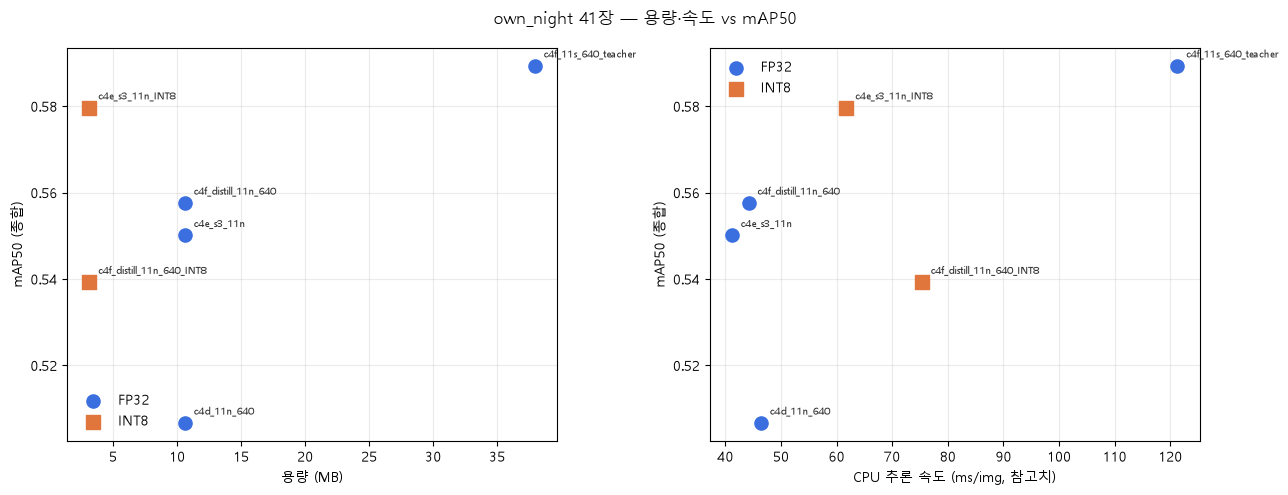

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
is_int8 = summary_df.index.str.endswith("INT8")

for ax, xcol, xlabel in ((axes[0], "용량(MB)", "용량 (MB)"),
                          (axes[1], "CPU속도(ms/img)", "CPU 추론 속도 (ms/img, 참고치)")):
    ax.scatter(summary_df.loc[~is_int8, xcol], summary_df.loc[~is_int8, "mAP50(종합)"],
               s=90, marker="o", color="#3B6FE0", label="FP32", zorder=3)
    ax.scatter(summary_df.loc[is_int8, xcol], summary_df.loc[is_int8, "mAP50(종합)"],
               s=90, marker="s", color="#E0763B", label="INT8", zorder=3)
    for name, row in summary_df.iterrows():
        ax.annotate(name, (row[xcol], row["mAP50(종합)"]),
                   textcoords="offset points", xytext=(6, 6), fontsize=7.5, color="#333333")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("mAP50 (종합)")
    ax.grid(True, alpha=0.25, zorder=0)
    ax.legend(frameon=False)

fig.suptitle(f"own_night {cached['n_images']}장 — 용량·속도 vs mAP50")
plt.tight_layout()
plt.show()